In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df = pd.read_csv("Expanded Attendance Dataset.csv")

In [66]:
print(df.head())
print(df.tail())

  student_id           name   course       date   status
0      ST001  WONG YINH HUA  Chinese 2025-01-12  Present
1      ST001  WONG YINH HUA  Chinese 2025-01-12   Absent
2      ST002   LEE YONG KIT       IT 2025-05-12   Absent
3      ST002   LEE YONG KIT       IT 2025-05-12  Present
4      ST003      YAP YI DE     Tech 2025-05-12  Present
   student_id           name   course       date   status
49      ST003      YAP YI DE     Tech 2025-07-12  Present
50      ST004    TAN MUN KAI     Math 2025-07-12  Present
51      ST005    LIM ZHI WEI  English 2025-07-12   Absent
52      ST006  CHONG JIA HAO  Science 2025-07-12  Present
53      ST007  GAN CHEE YONG  Chinese 2025-07-12  Present


In [67]:
print("Dataset shape:", df.shape)

Dataset shape: (48, 5)


In [69]:
print(df.isnull().sum())

student_id    1
name          1
course        1
date          1
status        1
dtype: int64


In [43]:
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 0 to 53
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   student_id  47 non-null     object
 1   name        47 non-null     object
 2   course      47 non-null     object
 3   date        47 non-null     object
 4   status      47 non-null     object
dtypes: object(5)
memory usage: 2.2+ KB
None


In [46]:
df = df.drop_duplicates()

In [47]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 0 to 53
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   student_id  47 non-null     object
 1   name        47 non-null     object
 2   course      47 non-null     object
 3   date        47 non-null     object
 4   status      47 non-null     object
dtypes: object(5)
memory usage: 2.2+ KB
None


In [49]:
df["status"] = df["status"].map({"Present": 1, "Absent": 0})

In [54]:
attendance_rate = df.groupby("date")["status"].mean().reset_index()

Unique status values: [ 1.  0. nan]
        date    status  status_percent
0 2025-01-12  0.571429       57.142857
1 2025-02-12  0.714286       71.428571
2 2025-03-12  0.714286       71.428571
3 2025-04-12  0.571429       57.142857
4 2025-05-12  0.750000       75.000000


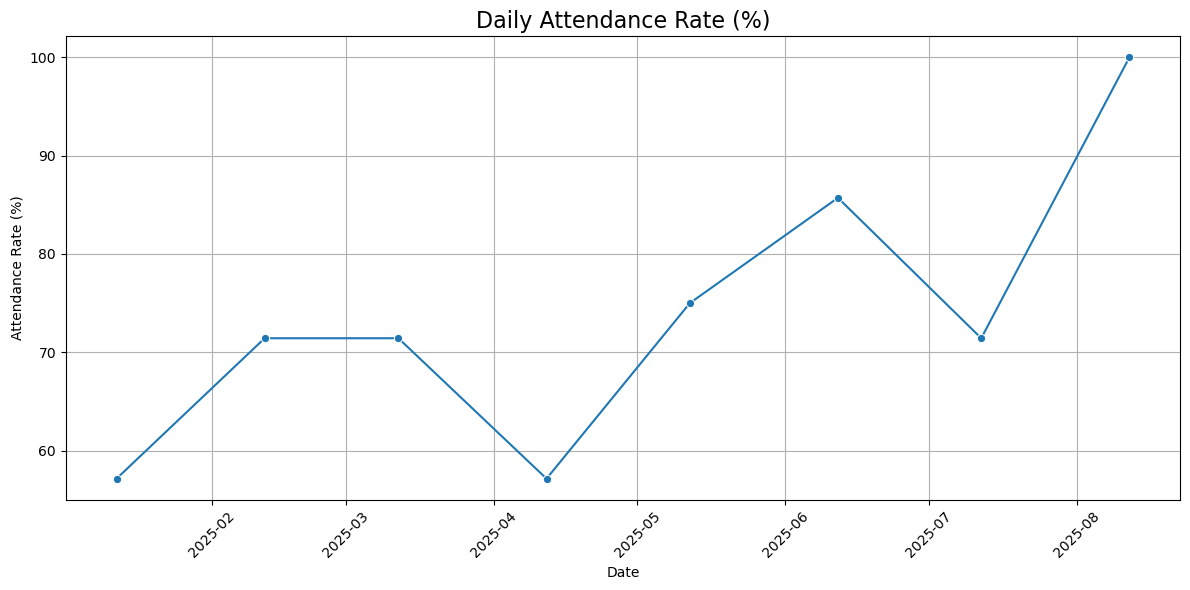

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv("Expanded Attendance Dataset.csv")

df = df.drop_duplicates()

df["date"] = pd.to_datetime(df["date"])

df["status"] = df["status"].map({"Present": 1, "Absent": 0})

print("Unique status values:", df["status"].unique())

attendance_rate = df.groupby("date")["status"].mean().reset_index()

attendance_rate["status_percent"] = attendance_rate["status"] * 100

print(attendance_rate.head())

plt.figure(figsize=(12,6))
sns.lineplot(data=attendance_rate, x="date", y="status_percent", marker="o")
plt.title("Daily Attendance Rate (%)", fontsize=16)
plt.ylabel("Attendance Rate (%)")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

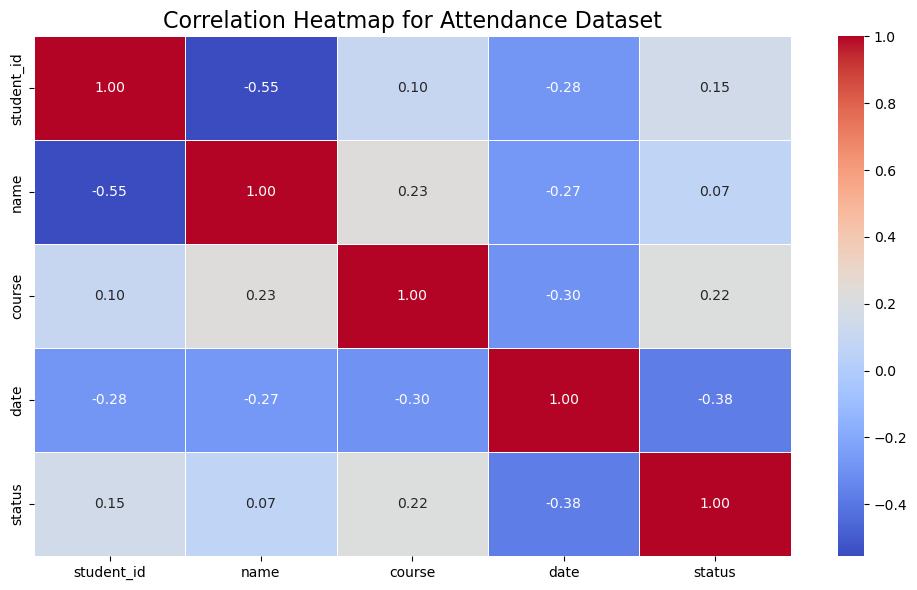

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("Expanded Attendance Dataset.csv")

df = df.drop_duplicates()

df["date"] = pd.to_datetime(df["date"])

label_enc = LabelEncoder()
for col in ["student_id", "name", "course", "status"]:
    df[col] = label_enc.fit_transform(df[col])

corr = df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Attendance Dataset", fontsize=16)
plt.tight_layout()
plt.show()

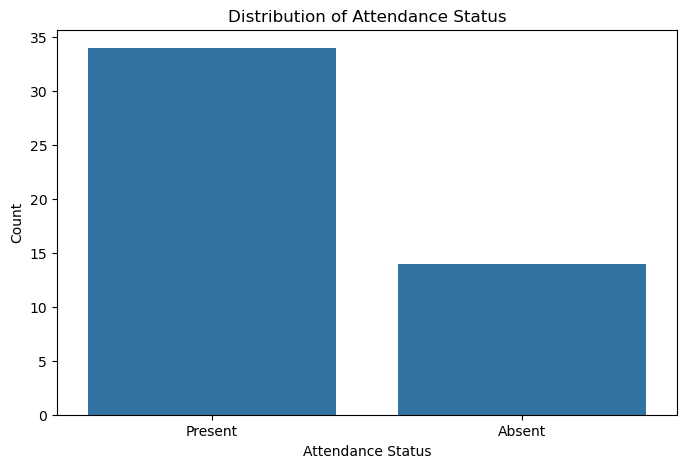

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Expanded Attendance Dataset.csv") 

plt.figure(figsize=(8,5))
sns.countplot(x="status", data=df)
plt.title("Distribution of Attendance Status")
plt.xlabel("Attendance Status")
plt.ylabel("Count")
plt.show()

In [110]:
X = df[["student_id", "name", "course", "year", "month", "day"]]
y = df["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 37
Testing samples: 10


In [112]:
# Train models
model1 = LinearRegression()
model2 = DecisionTreeRegressor(random_state=42)
model3 = RandomForestRegressor(random_state=42)

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)

# Predictions
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

In [117]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy_score(y_test, preds):.2f}")
    print(f"Precision: {precision_score(y_test, preds):.2f}")
    print(f"Recall: {recall_score(y_test, preds):.2f}")
    print(f"F1 Score: {f1_score(y_test, preds):.2f}")


Logistic Regression Performance:
Accuracy: 0.70
Precision: 0.70
Recall: 1.00
F1 Score: 0.82

Decision Tree Performance:
Accuracy: 0.50
Precision: 0.62
Recall: 0.71
F1 Score: 0.67

Random Forest Performance:
Accuracy: 0.40
Precision: 0.57
Recall: 0.57
F1 Score: 0.57


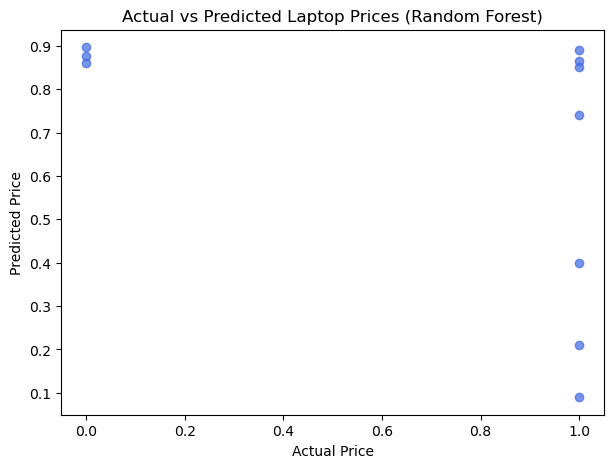

In [118]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, pred3, alpha=0.7, color='royalblue')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Laptop Prices (Random Forest)")
plt.show()